In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
import seaborn as sns
import pickle

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

sys.path.append("..")
from src import config

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


In [2]:

with open(config.POTATO_SPLITS_FILE, "rb") as f:
    splits = pickle.load(f)

X_train = splits['X_train']
y_train = splits['y_train']

X_val = splits['X_val']
y_val = splits['y_val']

X_test = splits['X_test']
y_test = splits['y_test']

POTATOES_CLASSES = splits['classes']
POTATOES_CLASS_DISPLAY = splits['class_display']

NUM_CLASSES = len(POTATOES_CLASSES)

print("Classes:")
for i, class_name in enumerate(POTATOES_CLASSES):
    print(f"  {i}: {POTATOES_CLASS_DISPLAY[class_name]}")

print(f"\nNumber of classes: {NUM_CLASSES}")

print("\nDataset sizes:")
print(f"Training:   {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test:       {len(X_test)}")


# CHECK IMAGE SHAPE

print(f"\nImage shape: {X_train.shape[1:]}")


Classes:
  0: Early Blight
  1: Late Blight
  2: Healthy

Number of classes: 3

Dataset sizes:
Training:   1506
Validation: 323
Test:       323

Image shape: (96, 96, 3)


In [3]:
# CLASS DISTRIBUTION

print("\nTraining class distribution:")

for class_id, class_name in enumerate(POTATOES_CLASSES):
    count = np.sum(y_train == class_id)
    print(f"  {POTATOES_CLASS_DISPLAY[class_name]}: {count}")


# CALCULATE CLASS WEIGHTS

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("\nClass weights:")

for class_id, weight in class_weights.items():
    print(
        f"  {POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[class_id]]}: "
        f"{weight:.3f}"
    )




Training class distribution:
  Early Blight: 700
  Late Blight: 700
  Healthy: 106

Class weights:
  Early Blight: 0.717
  Late Blight: 0.717
  Healthy: 4.736


In [4]:

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(X_train),
    reshuffle_each_iteration=True
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)


In [5]:
# DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        mode='horizontal'
    ),

    layers.RandomRotation(
        factor=0.07
    ),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomBrightness(
        factor=0.15
    )
], name="data_augmentation")


# BUILD MOBILENETV2

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained MobileNetV2
base_model.trainable = False


# BUILD COMPLETE MODEL

inputs = layers.Input(
    shape=(96, 96, 3),
    name="potato_leaf_image"
)

# Training augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = preprocess_input(x)

# Feature extraction
x = base_model(
    x,
    training=False
)

# Convert feature maps into one feature vector
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dropout(0.3)(x)

x = layers.Dense(
    128,
    activation='relu'
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    name="disease_prediction"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="PotatoDiseaseMobileNetV2"
)

# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()


Model: "PotatoDiseaseMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ potato_leaf_image (InputLayer)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_prediction (Dense)      │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
EPOCHS = 25
CHECKPOINT = config.POTATO_MODEL_BEST

history = model.fit(
    train_dataset,

    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        ),
        ModelCheckpoint(CHECKPOINT, 
            monitor="val_accuracy",
            save_best_only=True, 
            verbose=1),
    ]     
)

best = max(history.history["val_accuracy"])
print(f"\n Best val accuracy: {best:.4f}")
print(f" Model saved: {CHECKPOINT}")

c:\Users\HP\Downloads\Plant Dieases Classification Model\.myvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.7795 - loss: 0.5880
Epoch 1: val_accuracy improved from None to 0.83901, saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\potato_mobilenet_v2.keras

Epoch 1: finished saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\potato_mobilenet_v2.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 449ms/step - accuracy: 0.7795 - loss: 0.5880 - val_accuracy: 0.8390 - val_loss: 0.4664 - learning_rate: 0.0010
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8977 - loss: 0.2356
Epoch 2: val_accuracy improved from 0.83901 to 0.92879, saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\potato_mobilenet_v2.keras

Epoch 2: finished saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\potato_mobilenet_v2.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - accuracy: 0.8977 - loss: 0.2356 - val_accuracy: 0.9288 - val_loss: 0.1627 - learning_ra

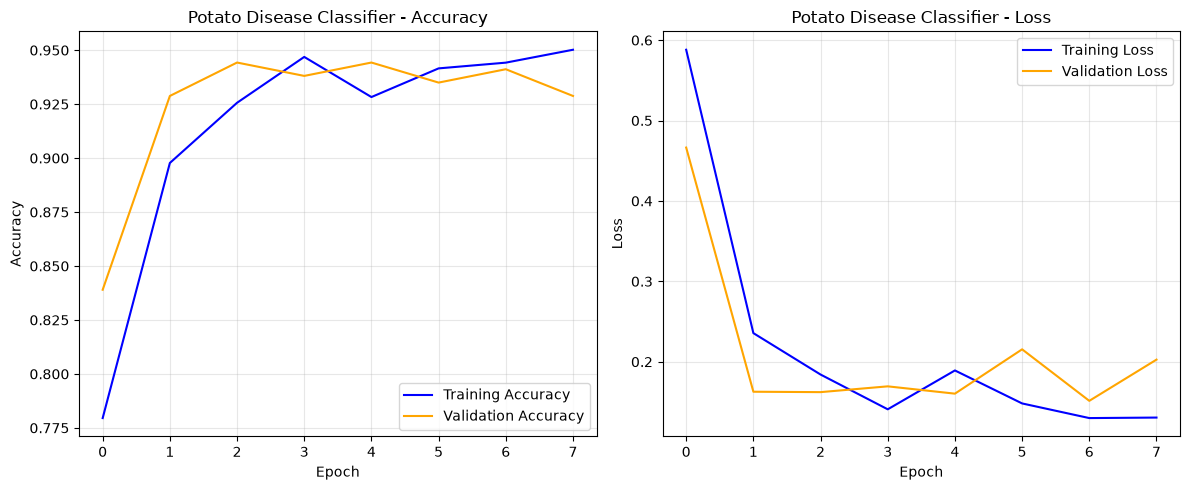

In [9]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(
    history.history['accuracy'], 
    label='Training Accuracy', 
    color='blue'
)
ax1.plot(
    history.history['val_accuracy'], 
    label='Validation Accuracy', 
    color='orange'
)
ax1.set_title('Potato Disease Classifier - Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)


ax2.plot(
    history.history['loss'], 
    label='Training Loss', 
    color='blue'
)
ax2.plot(
    history.history['val_loss'], 
    label='Validation Loss', 
    color='orange'
)
ax2.set_title('Potato Disease Classifier - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.savefig(
    f"{config.DOCS_DIR}/potato_training_v2_history.png", 
    dpi=120
)
plt.show()

In [12]:
import json

metadata = {
    "model_name": "potato_mobilenet",
    "classes": config.POTATOES_CLASSES,
    "class_display": config.POTATOES_CLASS_DISPLAY,
    "num_classes": len(config.POTATOES_CLASSES),
    "img_size": config.IMG_SIZE,
    "img_channels": 3,
    "uses_preprocess_input": True,   
    "expected_input_range": [0, 255],
    "expected_input_dtype": "uint8",
    "architecture": "MobileNetV2",
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
}

with open(config.POTATO_MODEL_META, "w") as f:
    json.dump(metadata, f, indent=2)

print(f" Metadata saved: {config.POTATO_MODEL_META}")
print(json.dumps(metadata, indent=2))

 Metadata saved: c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\potato_mobilenet_meta.json
{
  "model_name": "potato_mobilenet",
  "classes": [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
  ],
  "class_display": {
    "Potato___Early_blight": "Early Blight",
    "Potato___Late_blight": "Late Blight",
    "Potato___healthy": "Healthy"
  },
  "num_classes": 3,
  "img_size": 96,
  "img_channels": 3,
  "uses_preprocess_input": true,
  "expected_input_range": [
    0,
    255
  ],
  "expected_input_dtype": "uint8",
  "architecture": "MobileNetV2",
  "train_size": 1506,
  "val_size": 323,
  "test_size": 323,
  "best_val_accuracy": 0.9442724585533142
}


In [13]:

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    f"\nTEST ACCURACY: "
    f"{test_accuracy:.4f}"
)

print(
    f"TEST LOSS: "
    f"{test_loss:.4f}"
)

y_probability = model.predict(
    test_dataset,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

display_names = [
    POTATOES_CLASS_DISPLAY[class_name]
    for class_name in POTATOES_CLASSES
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=display_names,
        zero_division=0
    )
)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.9381 - loss: 0.1662

TEST ACCURACY: 0.9381
TEST LOSS: 0.1662
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 542ms/step

Classification Report:

              precision    recall  f1-score   support

Early Blight       0.99      0.97      0.98       150
 Late Blight       0.96      0.91      0.93       150
     Healthy       0.63      0.96      0.76        23

    accuracy                           0.94       323
   macro avg       0.86      0.94      0.89       323
weighted avg       0.95      0.94      0.94       323




Confusion Matrix:
[[145   5   0]
 [  1 136  13]
 [  0   1  22]]


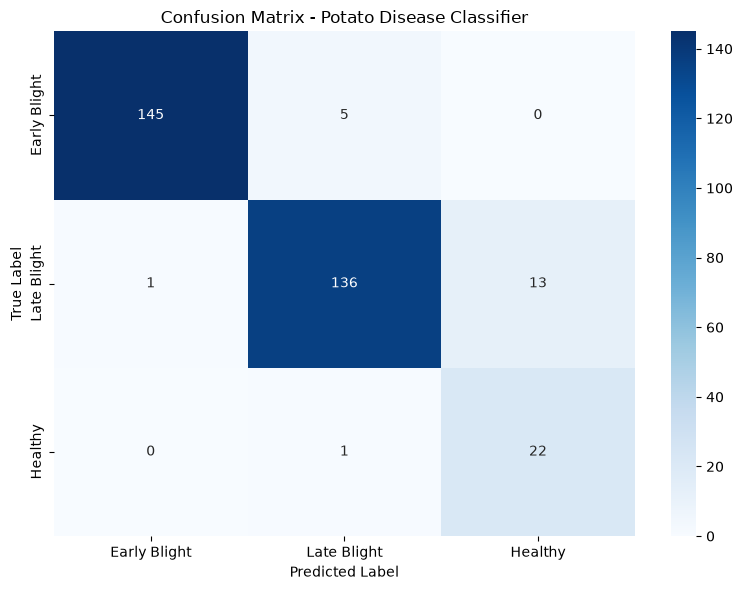

In [15]:

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=display_names,
    yticklabels=display_names
)

plt.title(
    'Confusion Matrix - Potato Disease Classifier'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig(
    f"{config.DOCS_DIR}/potato_confusion_v2_matrix.png", 
    dpi=150

)

plt.show()

In [16]:

# ERROR ANALYSIS - FIND INCORRECT PREDICTIONS

wrong_indices = np.where(y_test != y_pred)[0]

print(f"Total test images: {len(y_test)}")
print(f"Incorrect predictions: {len(wrong_indices)}")
print(f"Test accuracy: {(len(y_test) - len(wrong_indices)) / len(y_test):.4f}")

Total test images: 323
Incorrect predictions: 20
Test accuracy: 0.9381


In [18]:
print("\nIncorrect Predictions:\n")

for idx in wrong_indices:

    true_class = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[y_test[idx]]]
    predicted_class = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[y_pred[idx]]]

    print(
        f"Index {idx}: "
        f"True = {true_class} | "
        f"Predicted = {predicted_class}"
    )


Incorrect Predictions:

Index 1: True = Late Blight | Predicted = Healthy
Index 21: True = Healthy | Predicted = Late Blight
Index 55: True = Early Blight | Predicted = Late Blight
Index 69: True = Late Blight | Predicted = Healthy
Index 85: True = Late Blight | Predicted = Healthy
Index 97: True = Late Blight | Predicted = Healthy
Index 125: True = Late Blight | Predicted = Healthy
Index 145: True = Late Blight | Predicted = Healthy
Index 163: True = Early Blight | Predicted = Late Blight
Index 172: True = Late Blight | Predicted = Healthy
Index 188: True = Late Blight | Predicted = Healthy
Index 195: True = Late Blight | Predicted = Healthy
Index 197: True = Early Blight | Predicted = Late Blight
Index 216: True = Late Blight | Predicted = Healthy
Index 233: True = Late Blight | Predicted = Healthy
Index 243: True = Late Blight | Predicted = Early Blight
Index 261: True = Early Blight | Predicted = Late Blight
Index 280: True = Early Blight | Predicted = Late Blight
Index 283: True 

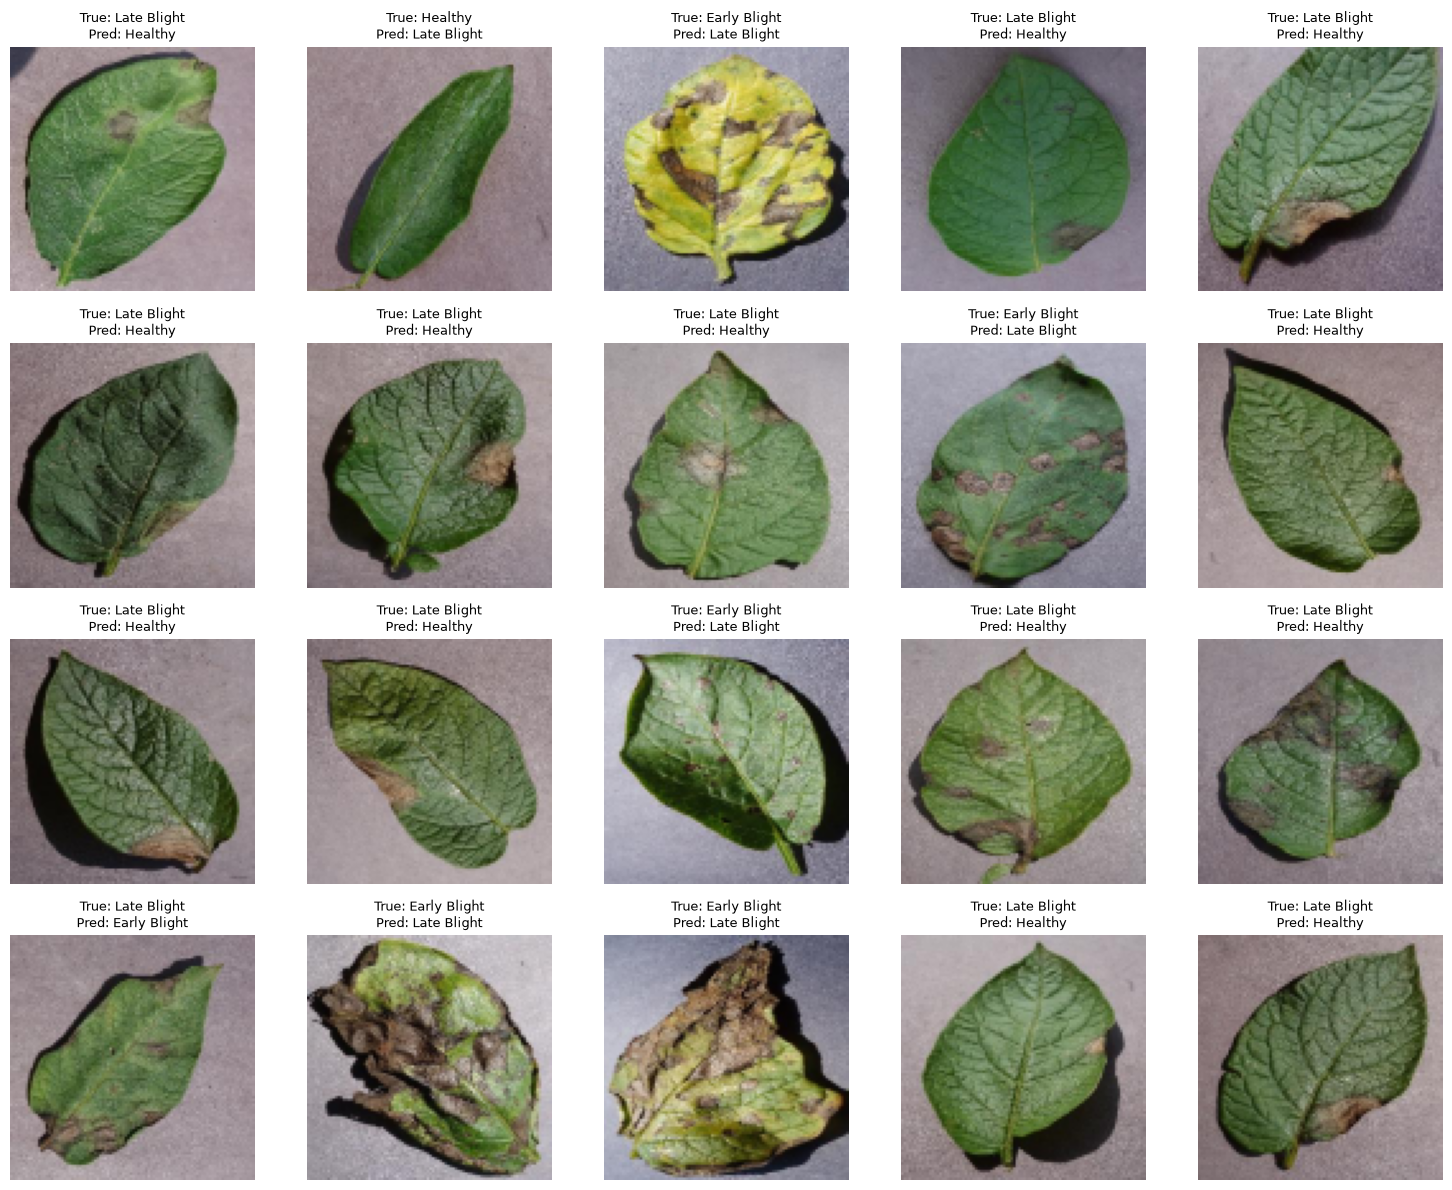

In [19]:

# DISPLAY INCORRECT PREDICTIONS

plt.figure(figsize=(15, 12))

for plot_num, idx in enumerate(wrong_indices):

    plt.subplot(4, 5, plot_num + 1)

    plt.imshow(X_test[idx])

    true_class = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[y_test[idx]]]
    predicted_class = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[y_pred[idx]]]

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    f"{config.DOCS_DIR}/potato_misclassified_v2_images.png",
    dpi=150
)

plt.show()

In [20]:

# LATE BLIGHT → HEALTHY ERRORS


late_to_healthy = []

for idx in wrong_indices:

    true_class = y_test[idx]
    predicted_class = y_pred[idx]

    if (
        POTATOES_CLASSES[true_class] == 'Potato___Late_blight'
        and
        POTATOES_CLASSES[predicted_class] == 'Potato___healthy'
    ):
        late_to_healthy.append(idx)

print(
    f"Late Blight → Healthy errors: "
    f"{len(late_to_healthy)}"
)

Late Blight → Healthy errors: 13


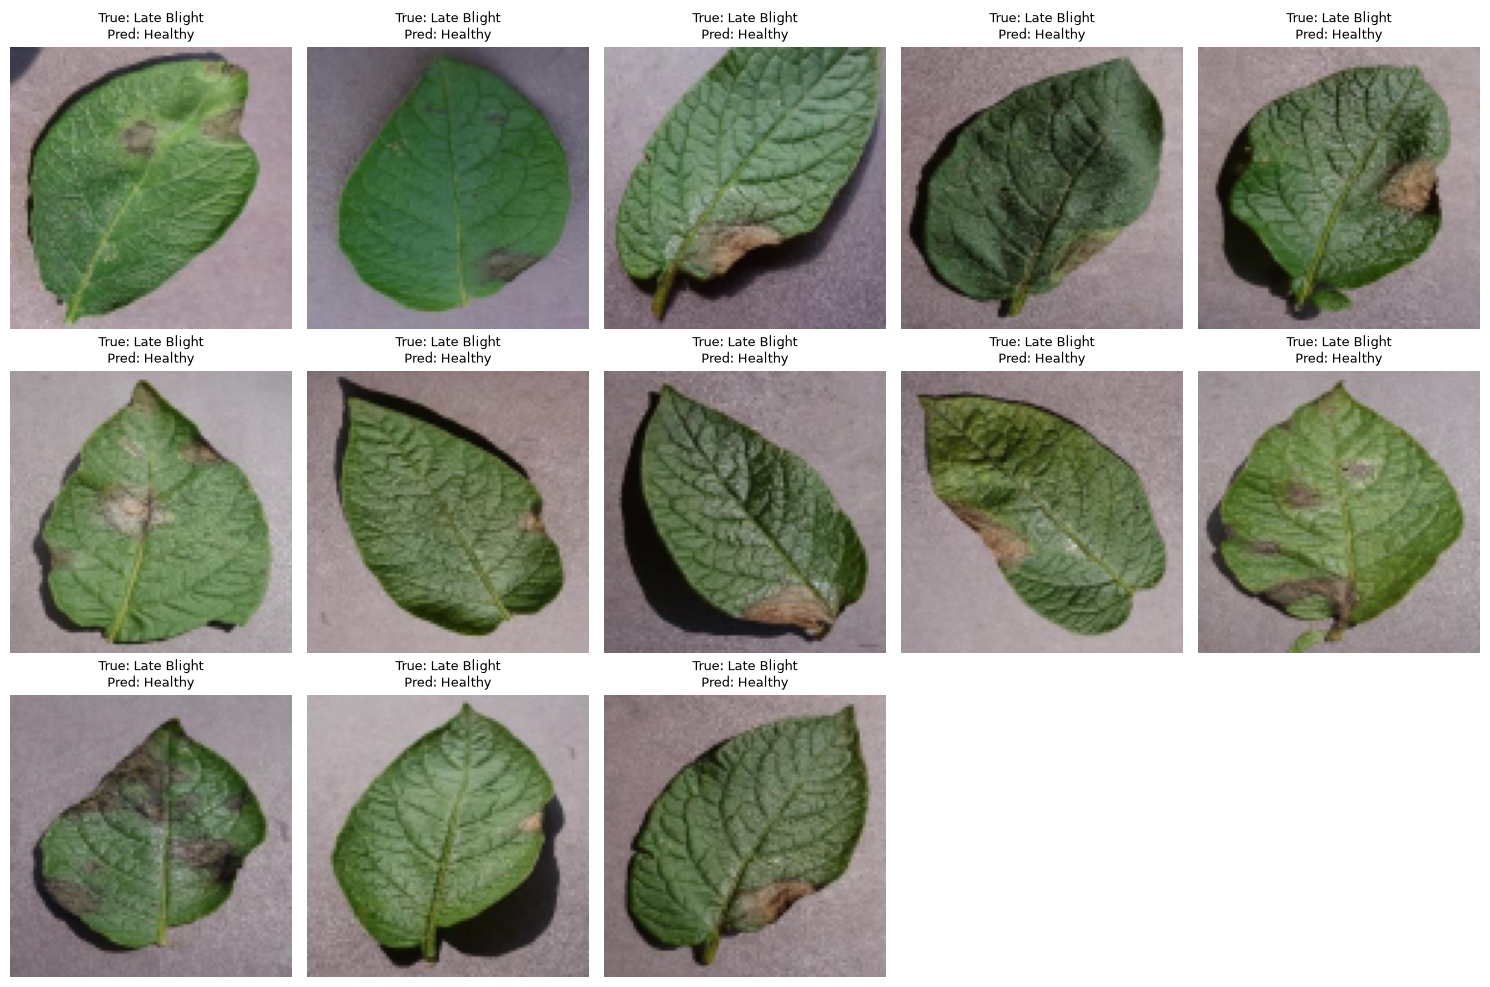

In [21]:
plt.figure(figsize=(15, 10))

for plot_num, idx in enumerate(late_to_healthy):

    plt.subplot(3, 5, plot_num + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: Late Blight\n"
        f"Pred: Healthy",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(

     f"{config.DOCS_DIR}/late_to_healthy_v2_errors.png",
        dpi=150
)

plt.show()

In [22]:
# CONFIDENCE OF INCORRECT PREDICTIONS


print("\nIncorrect prediction confidence:\n")

for idx in wrong_indices:

    probabilities = y_probability[idx]

    predicted_class = y_pred[idx]
    confidence = probabilities[predicted_class]

    true_class = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[y_test[idx]]]
    predicted_name = POTATOES_CLASS_DISPLAY[POTATOES_CLASSES[predicted_class]]

    print(
        f"Index {idx} | "
        f"True: {true_class} | "
        f"Predicted: {predicted_name} | "
        f"Confidence: {confidence:.2%}"
    )


Incorrect prediction confidence:

Index 1 | True: Late Blight | Predicted: Healthy | Confidence: 58.13%
Index 21 | True: Healthy | Predicted: Late Blight | Confidence: 76.04%
Index 55 | True: Early Blight | Predicted: Late Blight | Confidence: 56.61%
Index 69 | True: Late Blight | Predicted: Healthy | Confidence: 98.62%
Index 85 | True: Late Blight | Predicted: Healthy | Confidence: 63.84%
Index 97 | True: Late Blight | Predicted: Healthy | Confidence: 98.02%
Index 125 | True: Late Blight | Predicted: Healthy | Confidence: 90.26%
Index 145 | True: Late Blight | Predicted: Healthy | Confidence: 58.61%
Index 163 | True: Early Blight | Predicted: Late Blight | Confidence: 90.57%
Index 172 | True: Late Blight | Predicted: Healthy | Confidence: 71.78%
Index 188 | True: Late Blight | Predicted: Healthy | Confidence: 95.28%
Index 195 | True: Late Blight | Predicted: Healthy | Confidence: 83.52%
Index 197 | True: Early Blight | Predicted: Late Blight | Confidence: 63.49%
Index 216 | True: Lat